# Phishing URL Detection — Hannousse Dataset (Lexical-Only, No TF-IDF)
Single model: 56 lexical numeric features only. TF-IDF removed for interpretability and cross-domain generalization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, roc_auc_score, f1_score
)
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

print("Libraries loaded.")


Libraries loaded.


In [4]:
# ==========================================
# 2. DATA LOADING
# ==========================================

df = pd.read_csv('dataset_phishing.csv')
df['target'] = df['status'].map({'phishing': 1, 'legitimate': 0})

# 56 lexical columns (cols 1–56, index 1:57)
lexical_cols = list(df.columns[1:57])

X = df[lexical_cols]
y = df['target']

print(f"Lexical features : {len(lexical_cols)}")
print(f"First: {lexical_cols[0]}  |  Last: {lexical_cols[-1]}")
print(f"Dataset size     : {len(df)}")
print(f"Phishing rate    : {y.mean():.3f}")


Lexical features : 56
First: length_url  |  Last: statistical_report
Dataset size     : 11430
Phishing rate    : 0.500


In [5]:
# ==========================================
# 3. TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")


Train: 9144  |  Test: 2286


In [6]:
# ==========================================
# 4. SCALE (fit on train only)
# ==========================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Feature matrix — train: {X_train_scaled.shape}, test: {X_test_scaled.shape}")


Feature matrix — train: (9144, 56), test: (2286, 56)


In [7]:
# ==========================================
# 5. MODEL DEFINITION
# ==========================================

def get_model(scale_pos_weight=1.0):
    clf_lgb = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        importance_type='gain', class_weight='balanced',
        verbose=-1, random_state=42
    )
    clf_xgb = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=8,
        tree_method='hist', scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', random_state=42
    )
    return VotingClassifier(
        estimators=[('lgb', clf_lgb), ('xgb', clf_xgb)],
        voting='soft'
    )

spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {spw:.2f}")


scale_pos_weight: 1.00


In [8]:
# ==========================================
# 6. TRAIN & EVALUATE
# ==========================================

model = get_model(scale_pos_weight=spw)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
f1  = f1_score(y_test, y_pred, pos_label=1)
cm  = confusion_matrix(y_test, y_pred)

print("=" * 50)
print("LEXICAL-ONLY MODEL — Test Set Results")
print("=" * 50)
print(f"Accuracy  : {acc:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print(f"F1 (phish): {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['legitimate', 'phishing']))


LEXICAL-ONLY MODEL — Test Set Results
Accuracy  : 0.9186
ROC-AUC   : 0.9756
F1 (phish): 0.9188

              precision    recall  f1-score   support

  legitimate       0.92      0.92      0.92      1143
    phishing       0.92      0.92      0.92      1143

    accuracy                           0.92      2286
   macro avg       0.92      0.92      0.92      2286
weighted avg       0.92      0.92      0.92      2286



c:\Users\justi\Desktop\Phishing Detection Part 2\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\justi\Desktop\Phishing Detection Part 2\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
# ==========================================
# 7. CROSS-VALIDATION
# ==========================================

print("Running 5-fold Stratified CV...")

X_all_scaled = scaler.transform(X)   # transform full dataset using train-fitted scaler
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cvm = get_model(scale_pos_weight=spw)

cv_acc = cross_val_score(cvm, X_all_scaled, y, cv=cv, scoring='accuracy', n_jobs=-1)
cv_auc = cross_val_score(cvm, X_all_scaled, y, cv=cv, scoring='roc_auc',  n_jobs=-1)
cv_f1  = cross_val_score(cvm, X_all_scaled, y, cv=cv, scoring='f1',       n_jobs=-1)

print(f"CV Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"CV ROC-AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"CV F1(phish): {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")


Running 5-fold Stratified CV...
CV Accuracy : 0.9164 ± 0.0059
CV ROC-AUC  : 0.9739 ± 0.0017
CV F1(phish): 0.9166 ± 0.0053


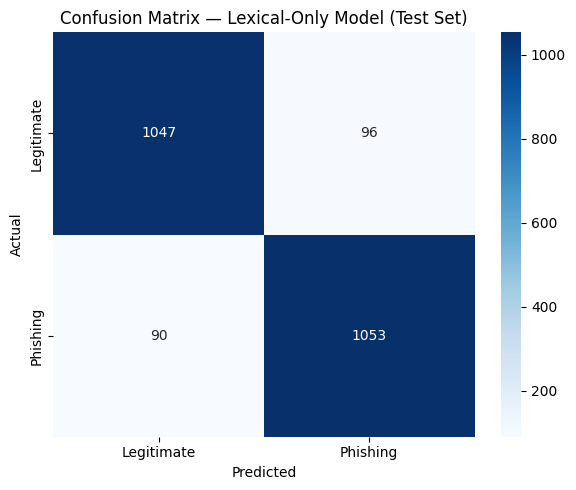

In [10]:
# ==========================================
# 8. CONFUSION MATRIX
# ==========================================

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
ax.set_title('Confusion Matrix — Lexical-Only Model (Test Set)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_lexical.png', dpi=150, bbox_inches='tight')
plt.show()


c:\Users\justi\Desktop\Phishing Detection Part 2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


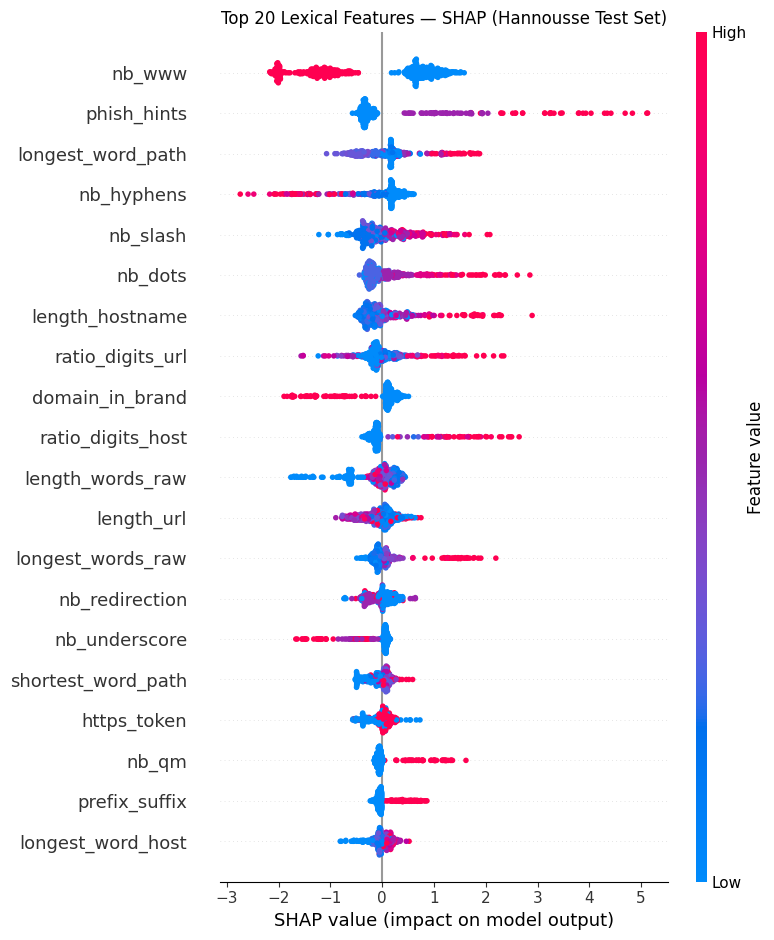

Saved: shap_summary_lexical.png


In [11]:
# ==========================================
# 9. SHAP FEATURE IMPORTANCE
# ==========================================
import shap

xgb_model = model.named_estimators_['xgb']

sample_idx  = np.random.choice(X_test_scaled.shape[0],
                                size=min(500, X_test_scaled.shape[0]),
                                replace=False)
X_shap      = X_test_scaled[sample_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, feature_names=lexical_cols,
                  max_display=20, show=False)
plt.title("Top 20 Lexical Features — SHAP (Hannousse Test Set)")
plt.tight_layout()
plt.savefig('shap_summary_lexical.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_lexical.png")


In [12]:
# ==========================================
# 10. SAVE ARTIFACTS
# ==========================================

joblib.dump(scaler, 'lexical_scaler.pkl')
joblib.dump(model,  'lexical_model.pkl')

print("Saved:")
print("  lexical_scaler.pkl  — StandardScaler fitted on 56 lexical train columns")
print("  lexical_model.pkl   — VotingClassifier (LightGBM + XGBoost)")
print()
print("Inference pipeline:")
print("  1. Extract 56 lexical features from URL")
print("  2. scaler.transform(X_new)")
print("  3. model.predict(X_scaled)")


Saved:
  lexical_scaler.pkl  — StandardScaler fitted on 56 lexical train columns
  lexical_model.pkl   — VotingClassifier (LightGBM + XGBoost)

Inference pipeline:
  1. Extract 56 lexical features from URL
  2. scaler.transform(X_new)
  3. model.predict(X_scaled)
